#  Decision Tree

In any classification task, we want certainity (classify data correctly) in classification, what if data itself is not linearly seprable ,but may be subset of the data is linearly classifiable

Decision tree is a greedy Search algorithm that is trying to divide data into small dataset that are linearly classifiable

In [1]:
# before going into how we can divide data into small datasets that 

In [2]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
x = np.random.random((2,200))

y = ((x[1] <0.5) & (x[0]>0.5)) | ((x[1] >0.5) & (x[0]<0.5))*1

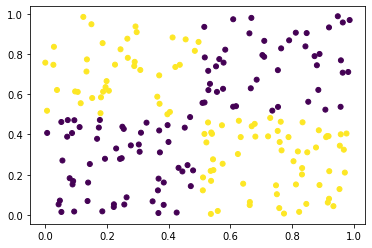

In [4]:
plt.scatter(x[0], x[1], marker='o', c=y,  s=25)

# Putrity:

Any data is said to be pure if all the samples have same class. This measure is usefull in Decision tree to find out weather we need to do more splitting or not.

Pure data will have zero entropy.

In [5]:
def purity_test(Y):   
    unique_classes = np.unique(Y)
    return len(unique_classes) == 1

print(purity_test([1,0,1,0]))
print(purity_test([1,1,1,1]))

False
True


In [6]:
def classify_data_using_mode(Y):
    return stats.mode(Y).mode[0]

print(classify_data_using_mode([1,0,1,0]))
print(classify_data_using_mode([1,1,1,1]))

0
1


### How can we find Potential Split in for a particular Variable?

We can sort all points for that one feature on which we want to split data,
and then our potential split would be mid points of all subsequent point. 

with each split we want certanity to increase and the split that gives us best increase in certanity can be said as best split. 

In [7]:
def get_potential_splits(data):
    potential_splits = {}
    n_columns, _ = data.shape
    for column_index in range(n_columns):        
        potential_splits[column_index] = []
        values = data[column_index,:]
        unique_values = np.unique(values)
        for index in range(len(unique_values)):
            if index != 0:
                current_value = unique_values[index]
                previous_value = unique_values[index - 1]
                potential_split = (current_value + previous_value) / 2
                potential_splits[column_index].append(potential_split)
    return potential_splits

In [8]:
potential_splits = get_potential_splits(x)

In [9]:
def split_data(x, y, split_column, split_value):
    split_column_values = x[split_column,:]

    x_below = x[:,np.where(split_column_values <= split_value)]
    y_below = y[np.where(split_column_values <= split_value)]
    x_above = x[:,np.where(split_column_values > split_value)]
    y_above = y[np.where(split_column_values > split_value)]
    
    return x_above.squeeze(axis=1),y_above, x_below.squeeze(axis=1),y_below

In [10]:
data_above,y_above, data_below,y_below = split_data(x,y, 0, 0.5)

print(x.shape,data_below.shape,y_below.shape,data_above.shape,y_above.shape)

(2, 200) (2, 95) (95,) (2, 105) (105,)


In [11]:
def calculate_entropy(y):
    _, counts = np.unique(y, return_counts=True)

    probabilities = counts / counts.sum()
    entropy = sum(probabilities * -np.log2(probabilities))
     
    return entropy

In [12]:
calculate_entropy(y)

1.0

In [13]:
def calculate_overall_entropy(data_below, data_above):
    
    n = len(data_below) + len(data_above)
    p_data_below = len(data_below) / n
    p_data_above = len(data_above) / n

    overall_entropy =  (p_data_below * calculate_entropy(data_below) 
                      + p_data_above * calculate_entropy(data_above))
    
    return overall_entropy

In [14]:
calculate_overall_entropy(y_below, y_above)

0.9836666451784284

In [15]:
def determine_best_split(x,y, potential_splits):
    
    overall_entropy = 9999
    for column_index in potential_splits:
        for value in potential_splits[column_index]:
            data_above, y_above, data_below, y_below = split_data(x,y, 
                                                                  split_column=column_index, 
                                                                  split_value=value)
            
            current_overall_entropy = calculate_overall_entropy(y_above, y_below)

            if current_overall_entropy <= overall_entropy:
                overall_entropy = current_overall_entropy
                best_split_column = column_index
                best_split_value = value
                
    return best_split_column, best_split_value

In [16]:
determine_best_split(x,y, potential_splits)

(0, 0.535473152765809)

In [17]:
def decision_tree_algorithm(x, y, depth=0, min_samples=2, max_depth=5):    
    
    
    # base cases
    if (purity_test(y)) or (len(y) < min_samples) or (depth == max_depth):
        classification = classify_data_using_mode(y)
        
        return "{}".format(round(classification,2))

    
    # recursive part
    else:    
        depth += 1

        # helper functions 
        potential_splits = get_potential_splits(x)
        split_column, split_value = determine_best_split(x, y, potential_splits)
        data_above,y_above, data_below,y_below  = split_data(x, y, split_column, split_value)
        
        # instantiate sub-tree
        question = "{} <= {}".format(split_column, split_value)
        sub_tree = {question: {}}
        
        # find answers (recursion)
        yes_answer = decision_tree_algorithm(data_below, y_below, depth, min_samples, max_depth)
        no_answer = decision_tree_algorithm(data_above, y_above, depth, min_samples, max_depth)
        
        # If the answers are the same, then there is no point in asking the qestion.
        # This could happen when the data is classified even though it is not pure
        # yet (min_samples or max_depth base cases).
        if yes_answer == no_answer:
            sub_tree = yes_answer
        else:
            if type(yes_answer)==dict:
                sub_tree[question]["yes"] = yes_answer
            else:
                sub_tree[question]["yes"] = {"Branch prediction {}".format(yes_answer):{}}
            if type(no_answer)==dict:
                sub_tree[question]["no"] = no_answer
            else:
                sub_tree[question]["no"] = {"Branch prediction {}".format(no_answer):{}}
        
        return sub_tree

In [18]:
tree = decision_tree_algorithm(x,y, max_depth=6)

print(tree)

{'0 <= 0.535473152765809': {'yes': {'1 <= 0.49359910694188647': {'yes': {'0 <= 0.4953384686641447': {'yes': {'Branch prediction 0': {}}, 'no': {'Branch prediction 1': {}}}}, 'no': {'0 <= 0.5036271401572106': {'yes': {'Branch prediction 1': {}}, 'no': {'Branch prediction 0': {}}}}}}, 'no': {'1 <= 0.5005090808868224': {'yes': {'Branch prediction 1': {}}, 'no': {'Branch prediction 0': {}}}}}}


In [19]:
import pydot

menu = tree

def draw(parent_name, child_name,depth,color='blue'):
    edge = pydot.Edge("{}".format(parent_name), 
                      "{}".format(child_name),
                      color=color)
    graph.add_edge(edge)

def visit(node,depth, parent=None):
    for k,v in node.items():
        if isinstance(v, dict):
            # We start with the root node whose parent is None
            # we don't want to graph the None node
            if parent:
                if 'yes' in v.keys():   
                    draw(parent, list(v['yes'].keys())[0] ,depth,'green')
                    visit(v['yes'], depth+1, list(v['yes'].keys())[0])
                elif 'no' in v.keys():
                    draw(parent, list(v['no'].keys())[0],depth,'red')
                    visit(v["no"], depth+1,list(v['no'].keys())[0])
                elif k =="yes":
                    draw(parent, list(v.keys())[0],depth,'green')
                    visit(v[list(v.keys())[0]],depth, list(v.keys())[0])
                elif k =="no":
                    draw(parent, list(v.keys())[0],depth,'red')
                    visit(v[list(v.keys())[0]],depth, list(v.keys())[0])
                else:
                    draw(parent, k, depth)
                    visit(v, depth+1,k)
            else:
                visit(v,depth+1,k)              
                    
        else:
            draw(parent, k, depth)
            # drawing the label using a distinct name
            draw(k, k+'_'+v, depth)

graph = pydot.Dot(graph_type='graph')
visit(menu,0)

In [20]:
graph.write_png('example1_graph_classi.png')

In [21]:
menu = tree

def tree_to_python_if_else(node,depth, parent=None):
    output = ""
    for k,v in node.items():
        if isinstance(v, dict):            
            if 'Branch prediction' in k:
                output+="{}output = {}\n".format("  "*depth,k.replace("Branch prediction","").strip())
            elif 'yes' in v:
                output+= "{}if (var_{}):\n".format("  "*depth, k)
                output+=tree_to_python_if_else(v["yes"],depth+1,k)  
                output+= "{}else:\n".format("  "*depth)
                output+=tree_to_python_if_else(v["no"],depth+1,k)                  
        else:
            print("\nnot dict:",k,v)
    return output

tree_python_code = tree_to_python_if_else(menu,0)

In [22]:
print(tree_python_code)

if (var_0 <= 0.535473152765809):
  if (var_1 <= 0.49359910694188647):
    if (var_0 <= 0.4953384686641447):
      output = 0
    else:
      output = 1
  else:
    if (var_0 <= 0.5036271401572106):
      output = 1
    else:
      output = 0
else:
  if (var_1 <= 0.5005090808868224):
    output = 1
  else:
    output = 0



In [23]:
def predict(tree, data):    
    for i in range(len(data)):
        exec("var_{} = {}".format(i, data[i]), locals())
    exec(tree, locals()) 
    return locals()['output']

In [24]:
print("data point is :",x[:,0])
print("predicted class:",predict(tree_python_code,x[:,0]))

data point is : [0.5407991  0.40332284]
predicted class: 1


In [25]:
y_pred = [predict(tree_python_code, x[:,i]) for i in range(x.shape[1])]


In [26]:
1 - np.mean((np.abs(np.array(y_pred)-y)))

1.0

In [28]:
x[0, :].max()+1

1.987271285392338

In [29]:
x_min, x_max = x[0, :].min() - 0.1, x[0, :].max() + 0.1
y_min, y_max = x[1, :].min() - 0.1, x[1, :].max() + 0.1
plot_step = 0.02

xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                     np.arange(y_min, y_max, plot_step))

In [30]:
output_z = []
for i in range(yy.shape[0]):
    temp = []
    for j in range(yy.shape[1]):
        temp.append(predict(tree_python_code, [xx[i,j],yy[i,j]]))
    output_z.append(temp)

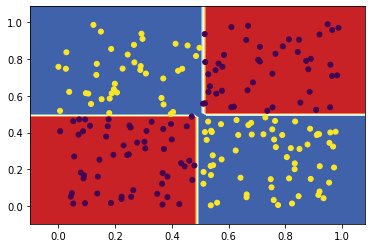

In [31]:
plt.contourf(xx, yy, np.array(output_z), cmap=plt.cm.RdYlBu)

plt.scatter(x[0], x[1], marker='o', c=y,  s=25)